Author: Nicolas Legrand <nicolas.legrand@cas.au.dk>

In [22]:
import numpy as np
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pingouin as pg
from pathlib import Path

plt.rcParams["figure.constrained_layout.use"] = True

# ROC-AUC curve visualisation

In [75]:
results = {"auc": [], "color": [], "model": []}

In [76]:
standard_model_hgf_df = pd.read_csv(
    Path.cwd().parent.parent / "results" / "standard_model_summary.csv"
)
standard_model_hgf_df = standard_model_hgf_df[standard_model_hgf_df.session == 2]

variables_list = [
    ["extero_threshold", "intero_threshold"],
    ["extero_slope", "intero_slope"],
]

for variables, name in zip(variables_list, ["threshold", "slope"]):
    var_1, var_2 = variables
    auc = pg.compute_effsize(
        standard_model_hgf_df[var_1],
        standard_model_hgf_df[var_2],
        paired=False,
        eftype="AUC",
    )
    auc = auc if auc > 0.5 else 1.0 - auc
    results["auc"].append(auc)
    results["model"].append("dynamic_beliefs")
    results["color"].append("#92c396")

In [77]:
cardiac_believing_hgf_df = pd.read_csv(
    Path.cwd().parent.parent / "results" / "cardiac_believing_summary.csv"
)
cardiac_believing_hgf_df = cardiac_believing_hgf_df[
    cardiac_believing_hgf_df.session == 2
]

variables_list = [
    ["intero_mean", "extero_mean"],
    ["intero_std", "extero_std"],
]

for variables, name in zip(variables_list, ["threshold", "slope"]):
    var_1, var_2 = variables
    auc = pg.compute_effsize(
        cardiac_believing_hgf_df[var_1],
        cardiac_believing_hgf_df[var_2],
        paired=False,
        eftype="AUC",
    )
    auc = auc if auc > 0.5 else 1.0 - auc
    results["auc"].append(auc)
    results["model"].append("static_beliefs")
    results["color"].append("#6f94b5")

In [78]:
weighted_update_df = pd.read_csv(
    Path.cwd().parent.parent / "results" / "weighted_update_summary.csv"
)
weighted_update_df = weighted_update_df[weighted_update_df.session == 2]

variables_list = [
    ["logit_exteroceptive_sensitivity", "logit_interoceptive_sensitivity"],
    ["pi_cardiac_belief", "pi_extero_belief"],
    ["mu_cardiac_prior", "mu_extero_prior"],
]

for variables, name in zip(
    variables_list, ["logit_sensitivity", "belief_precision", "belief_mean"]
):
    var_1, var_2 = variables
    auc = pg.compute_effsize(
        weighted_update_df[var_1], weighted_update_df[var_2], paired=False, eftype="AUC"
    )
    auc = auc if auc > 0.5 else 1.0 - auc
    results["auc"].append(auc)
    results["model"].append("weighted_update")
    results["color"].append("#dca8ae")

In [79]:
cardiac_hgf_df = pd.read_csv(
    Path.cwd().parent.parent / "results" / "cardiac_hgf_summary.csv"
)
cardiac_hgf_df = cardiac_hgf_df[cardiac_hgf_df.session == 2]

variables_list = [
    ["logit_exteroceptive_sensitivity", "logit_interoceptive_sensitivity"],
    ["interoceptive_mean", "exteroceptive_mean"],
    ["interoceptive_precision", "exteroceptive_precision"],
]

for variables, name in zip(
    variables_list, ["logit_sensitivity", "belief_mean", "belief_precision"]
):
    var_1, var_2 = variables
    auc = pg.compute_effsize(
        cardiac_hgf_df[var_1], cardiac_hgf_df[var_2], paired=False, eftype="AUC"
    )
    auc = auc if auc > 0.5 else 1.0 - auc
    results["auc"].append(auc)
    results["model"].append("cardiac_hgf")
    results["color"].append("#a2618c")

In [89]:
auc = np.asarray(results["auc"])
colors = np.asarray(results["color"])
labels = np.asarray(results["model"])
sort_idxs = np.argsort(auc)

/tmp/ipykernel_44782/3985576626.py:34: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


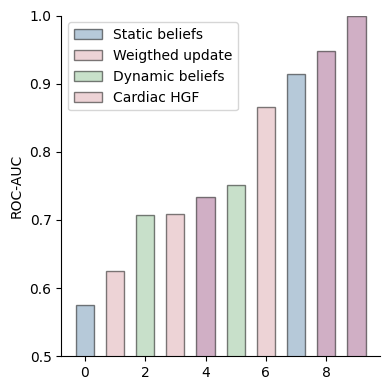

In [95]:
_, ax = plt.subplots(figsize=(4, 4))

# Use a set to track unique labels and avoid duplicates
seen_labels = set()
handles = []

for x, h, color, label in zip(
    range(10), auc[sort_idxs], colors[sort_idxs], labels[sort_idxs]
):
    # Only create bar and add to legend if label hasn't been seen before
    if label not in seen_labels:
        bar = ax.bar(
            x=x,
            height=h,
            width=0.6,
            color=color,
            edgecolor="black",
            linewidth=1.0,
            alpha=0.5,
            label=label,
        )
        handles.append(bar)
        seen_labels.add(label)
    else:
        # Create bar without label for duplicates
        ax.bar(
            x=x,
            height=h,
            width=0.6,
            color=color,
            edgecolor="black",
            linewidth=1.0,
            alpha=0.5,
        )

ax.set(ylim=(0.5, 1.0), ylabel="ROC-AUC")

# Move legend outside on the right
plt.legend(
    labels=["Static beliefs", "Weigthed update", "Dynamic beliefs", "Cardiac HGF"],
    loc="upper left",
)
sns.despine()

# Adjust layout to make space for the legend
plt.tight_layout()

plt.savefig(
    Path().cwd().parent.parent / "figures" / "figure_4_ROC_AUC.svg", bbox_inches="tight"
)